# **IMDB  Classification** (Sentiment Analysis)

___
By Abdullah

## Libraries

In [1]:
# !pip install tensorflow

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.text import text_to_word_sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import losses
from tensorflow.keras import metrics
from tensorflow.keras import optimizers

In [2]:
## ====> Libraries for Preprocessing

import re
import string
import nltk
nltk.download('all')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import unicodedata
import html
# stop_words = stopwords.words('english')

In [101]:
from sklearn.metrics import accuracy_score, classification_report

## Reading Dataset

In [58]:
from pathlib import Path
import os
DATA_PATH=Path('./dat/')
DATA_PATH.mkdir(exist_ok=True)
if not os.path.exists('./dat/aclImdb'):
    !curl -O http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
    !tar -xf aclImdb_v1.tar.gz -C {DATA_PATH}

In [59]:
CLASSES = ['neg', 'pos']
PATH=Path('./dat/aclImdb/')

def get_texts(path):
    texts,labels = [],[]
    for idx,label in enumerate(CLASSES):
        for fname in (path/label).glob('*.*'):
            texts.append(fname.open('r', encoding='utf-8').read())
            labels.append(idx)
    return texts, labels

In [60]:
trn_texts,trn_labels = get_texts(PATH/'train')
tst_texts,tst_labels = get_texts(PATH/'test')

In [61]:
for i in trn_texts[:15]:
  print(i, end='\n\n')

Predictable parody, just about failed to impress throughout it's looooooong eight minutes. The only thing that made it worthwhile was the DO NOT COLORIZE line at the end credits. Shame something more entertaining wasn't put on the DVD, like Jonathan Ross' enjoyable profile of Romero on 'The Incredible Strange Film Show.'

Painfully bad Christmas film that has an equally painfully bad performance by Vince Vaughn, who is paying his usual frat boy self but this time for a children's movie but with out the wit or charm that is in his R rated films. Vaughn seems like he's on autopilot though most of the film and he keeps running into walls with his lackluster performance. After 30 minutes into the film, you would be in touch your inner scourge and say "Bahumbag" at how unfunny this film is and after another 30 minutes, you will want to walk out over how unbearable the film has gotten during that point. Out of all the actors involved in this mess, only Paul Giamatti and Rachel Weisz brings s

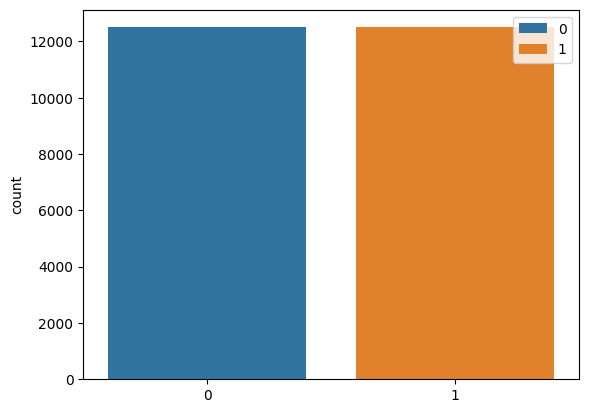

In [62]:
sns.countplot(x = trn_labels,hue=trn_labels)
plt.show()

## Preprocessing

In [63]:
def remove_special_chars(text):
    re1 = re.compile(r'  +')
    x1 = text.lower().replace('#39;', "'").replace('amp;', '&').replace('#146;', "'").replace(
        'nbsp;', ' ').replace('#36;', '$').replace('\\n', "\n").replace('quot;', "'").replace(
        '<br />', "\n").replace('\\"', '"').replace('<unk>', 'u_n').replace(' @.@ ', '.').replace(
        ' @-@ ', '-').replace('\\', ' \\ ').replace("I've", "I have").replace("i've", "i have")
    return re1.sub(' ', html.unescape(x1))


def remove_non_ascii(text):
    """Remove non-ASCII characters from list of tokenized words"""
    return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')


def to_lowercase(text):
    return text.lower()



def remove_punctuation(text):
    """Remove punctuation from list of tokenized words"""
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)


def replace_numbers(text):
    """Replace all interger occurrences in list of tokenized words with textual representation"""
    return re.sub(r'\d+', '', text)


def remove_whitespaces(text):
    return text.strip()


def remove_stopwords(words, stop_words):

    return [word for word in words if word not in stop_words]


# def stem_words(words):
#     """Stem words in text"""
#     stemmer = PorterStemmer()
#     return [stemmer.stem(word) for word in words]

def lemmatize_words(words):
    """Lemmatize words in text"""

    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(word) for word in words]

def lemmatize_verbs(words):
    """Lemmatize verbs in text"""

    lemmatizer = WordNetLemmatizer()
    return ' '.join([lemmatizer.lemmatize(word, pos='v') for word in words])

def text2words(text):
  return word_tokenize(text)

def normalize_text( text):
    text = remove_special_chars(text)
    text = remove_non_ascii(text)
    text = remove_punctuation(text)
    text = to_lowercase(text)
    text = replace_numbers(text)
    words = text2words(text)
    words = remove_stopwords(words, stop_words)
    words = lemmatize_words(words)
    words = lemmatize_verbs(words)

    return ''.join(words)

In [64]:
def normalize_corpus(corpus):
  return [normalize_text(t) for t in corpus]

In [65]:
trn_texts = normalize_corpus(trn_texts)
tst_texts = normalize_corpus(tst_texts)

In [66]:
for t in trn_texts[:10]:
  print(t,end='\n\n')

predictable parody fail impress throughout looooooong eight minute thing make worthwhile colorize line end credit shame something entertain wasnt put dvd like jonathan ross enjoyable profile romero incredible strange film show

painfully bad christmas film equally painfully bad performance vince vaughn pay usual frat boy self time childrens movie wit charm r rat film vaughn seem like he autopilot though film keep run wall lackluster performance minute film would touch inner scourge say bahumbag unfunny film another minute want walk unbearable film get point actor involve mess paul giamatti rachel weisz bring life perspective paper thin role thats manly way good actor film paul giamatti bring depth warmth character saint nick he force vaughns level juvenile behavior sad sibling infighting see giamatti face he fun role painfully show certain part film rachel weisz bring sense fun spirit role really much character work see face shes well aware much seem irritate certain part film fortunat

## Splitting

In [67]:
from sklearn.model_selection import train_test_split
y = np.array(trn_labels)

def splitting(X):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=88)
  return X_train, X_test, y_train, y_test


## Model

In [68]:

from tensorflow.keras.optimizers import AdamW
def ann_model(X_train, X_test, y_train, y_test, epoch=10):
  model = models.Sequential()

  model.add(layers.Dense(20, activation='relu')) # model.add(layers.Dense(32, activation='leaky_relu'))
  model.add(layers.Dropout(0.6))
  model.add(layers.Dense(1, activation='sigmoid'))
  model.summary()
  model.compile(
      optimizer=AdamW(learning_rate=0.005, weight_decay=0.004),
      # optimizer='adam',
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])
  history = model.fit(X_train,
                    y_train,
                    epochs=epoch,
                    batch_size=256,
                    validation_data=(X_test, y_test))
  return history ,model

In [69]:
def result_plot(history):
  history_dict = history.history

  acc = history_dict['binary_accuracy']
  val_acc = history_dict['val_binary_accuracy']
  loss = history_dict['loss']
  val_loss = history_dict['val_loss']
  epochs = range(1, len(acc) + 1)
  plt.clf()

  fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)


  ax1.plot(epochs, acc, 'bo', label='Training acc')
  ax1.plot(epochs, val_acc, 'b', label='Validation acc')
  ax1.set_title('Training and Validation Accuracy')
  ax1.set_ylabel('Accuracy')  # Corrected from 'Loss' to 'Accuracy'
  ax1.legend()
  ax1.grid(True)


  ax2.plot(epochs, loss, 'bo', label='Training loss')
  ax2.plot(epochs, val_loss, 'b', label='Validation loss')
  ax2.set_title('Training and Validation Loss')
  ax2.set_xlabel('Epochs')
  ax2.set_ylabel('Loss')
  ax2.legend()
  ax2.grid(True)

  plt.tight_layout()
  plt.show()

## Use the diff ways to Representation using Tensoflow & Keras

In [70]:
# texts = trn_texts + tst_texts
texts = trn_texts

In [71]:
vocab_sz = 20000 # None means all
tok = Tokenizer(num_words=vocab_sz, oov_token='UNK')
tok.fit_on_texts(texts)

In [72]:
len(tok.word_index)

91356

### 1. Count

In [73]:
bow1 = tok.texts_to_matrix(trn_texts , mode='count')
test_text_count = tok.texts_to_matrix(tst_texts , mode='count')
bow1[1]

array([0., 2., 4., ..., 0., 0., 0.])

In [74]:
type(bow1), type(test_text_count)

(numpy.ndarray, numpy.ndarray)

In [75]:
X_train_count, X_test_count, y_train_count, y_test_count = splitting(bow1)

In [76]:
type(X_train_count), type(X_test_count), type(y_train_count), len(y_test_count)

(numpy.ndarray, numpy.ndarray, numpy.ndarray, 5000)

In [77]:
history_count, model_coun = ann_model(X_train_count, X_test_count, y_train_count, y_test_count,15)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - binary_accuracy: 0.7686 - loss: 0.4877 - val_binary_accuracy: 0.8836 - val_loss: 0.2874
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - binary_accuracy: 0.8956 - loss: 0.2684 - val_binary_accuracy: 0.8868 - val_loss: 0.2838
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - binary_accuracy: 0.9213 - loss: 0.2099 - val_binary_accuracy: 0.8878 - val_loss: 0.2895
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - binary_accuracy: 0.9323 - loss: 0.1720 - val_binary_accuracy: 0.8892 - val_loss: 0.3022
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - binary_accuracy: 0.9456 - loss: 0.1425 - val_binary_accuracy: 0.8864 - val_loss: 0.3234
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - binary_accuracy: 0.9503 - loss: 0.1308 - val_binary_accuracy: 0.8840 - val_loss: 0.3558
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - binary_accuracy: 0.9537 - loss: 0.1114 - val_binary_accuracy: 0.8836 - val_loss: 0.3749
Epoch 8/15
79

<Figure size 640x480 with 0 Axes>

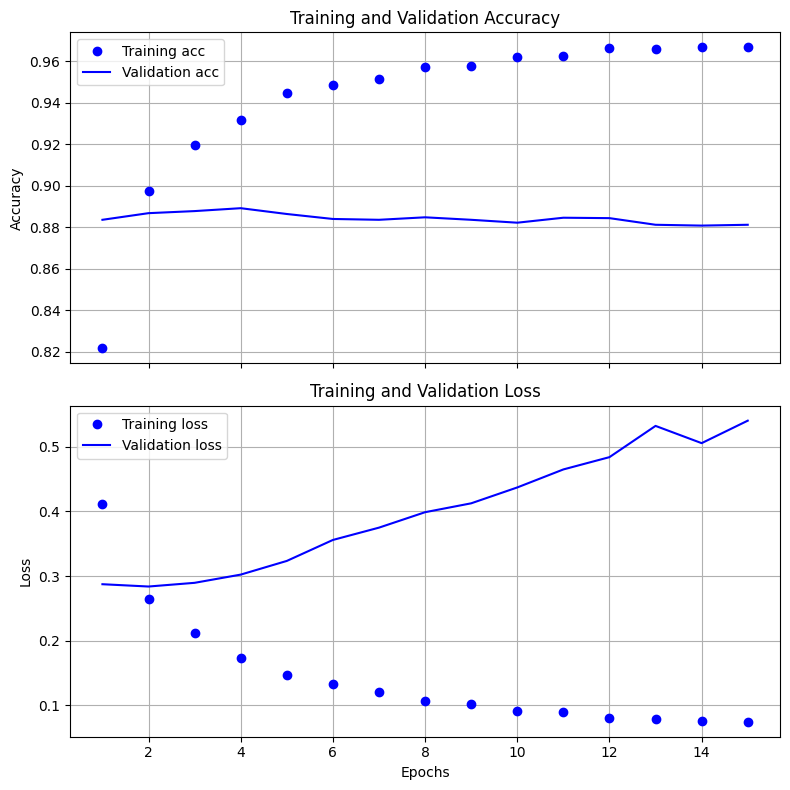

In [78]:
result_plot(history_count)

In [79]:
y_pred_count = model_coun.predict(test_text_count)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [80]:
test_text_count.shape

(25000, 20000)

In [81]:
(y_pred_count.shape)

(25000, 1)

In [82]:
binary_predictions = (y_pred_count >= 0.5).astype(int)

# Flatten if needed (removes extra dimensions)
binary_predictions = binary_predictions.flatten()

print(binary_predictions)

[0 0 0 ... 1 1 1]


In [83]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [84]:
accuracy_score(tst_labels, binary_predictions)

0.86088

In [85]:
confusion_matrix(tst_labels, binary_predictions)

array([[10714,  1786],
       [ 1692, 10808]])

In [103]:
print(classification_report(tst_labels, binary_predictions))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86     12500
           1       0.88      0.82      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



___
$$****************************$$
___

### Freq

In [86]:
bow2 = tok.texts_to_matrix(trn_texts , mode='freq')
test_text_freq = tok.texts_to_matrix(tst_texts , mode='freq')
bow2[9]

array([0.        , 0.02020202, 0.01010101, ..., 0.        , 0.        ,
       0.        ])

In [87]:
X_train_freq, X_test_freq, y_train_freq, y_test_freq = splitting(bow2)

In [88]:
history_freq, model_freq = ann_model(X_train_freq, X_test_freq, y_train_freq, y_test_freq,10)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - binary_accuracy: 0.6179 - loss: 0.6801 - val_binary_accuracy: 0.8376 - val_loss: 0.6044
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - binary_accuracy: 0.7700 - loss: 0.5733 - val_binary_accuracy: 0.8664 - val_loss: 0.4702
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - binary_accuracy: 0.8193 - loss: 0.4619 - val_binary_accuracy: 0.8764 - val_loss: 0.3902
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - binary_accuracy: 0.8497 - loss: 0.3931 - val_binary_accuracy: 0.8828 - val_loss: 0.3444
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - binary_accuracy: 0.8665 - loss: 0.3557 - val_binary_accuracy: 0.8868 - val_loss: 0.3144
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - binary_accuracy: 0.8771 - loss: 0.3197 - val_binary_accuracy: 0.8878 - val_loss: 0.2980
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - binary_accuracy: 0.8948 - loss: 0.2912 - val_binary_accuracy: 0.8894 - val_loss: 0.2871
Epoch 8/10
79

<Figure size 640x480 with 0 Axes>

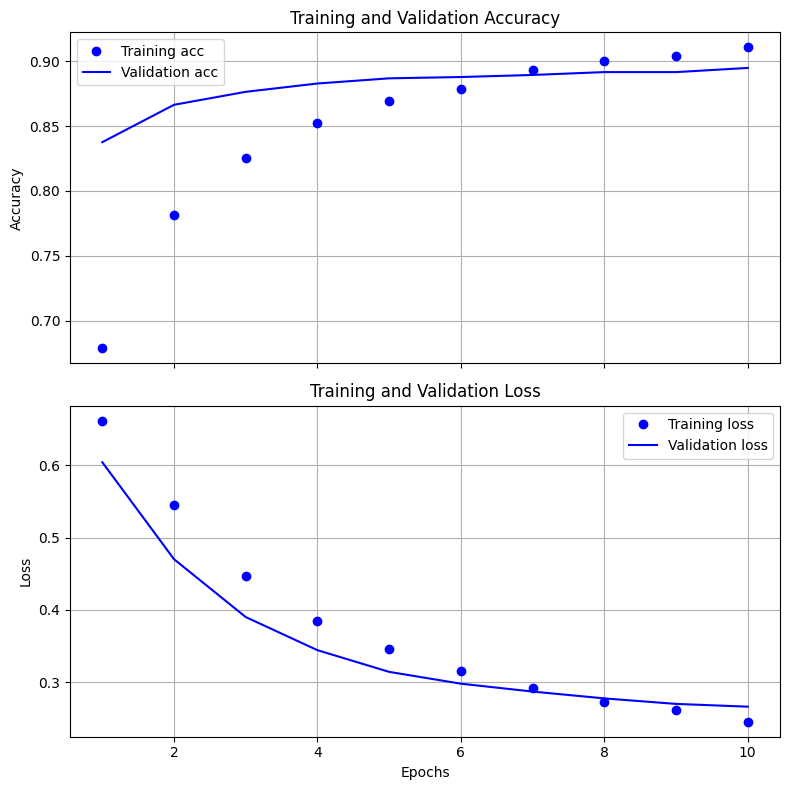

In [89]:
result_plot(history_freq)

In [90]:
y_pred_freq = model_freq.predict(test_text_freq)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [91]:
binary_predictions = (y_pred_freq >= 0.5).astype(int)
binary_predictions_freq = binary_predictions.flatten()

In [92]:
accuracy_score(tst_labels, binary_predictions_freq)

0.8816

In [93]:
confusion_matrix(tst_labels,binary_predictions_freq)

array([[11177,  1323],
       [ 1637, 10863]])

In [104]:
print(classification_report(tst_labels, binary_predictions_freq))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88     12500
           1       0.89      0.87      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



___
$$****************************$$
___

### TFIDF

In [94]:
bow3 = tok.texts_to_matrix(trn_texts , mode='tfidf')
test_text_tfidf= tok.texts_to_matrix(tst_texts , mode='tfidf')
bow3[9]

array([ 0.        , 17.14594463,  0.9377181 , ...,  0.        ,
        0.        ,  0.        ])

In [95]:
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = splitting(bow3)

In [96]:
history_tfidf, model_tfidf= ann_model(X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf,20)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - binary_accuracy: 0.7604 - loss: 0.4970 - val_binary_accuracy: 0.8826 - val_loss: 0.2927
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - binary_accuracy: 0.9057 - loss: 0.2590 - val_binary_accuracy: 0.8830 - val_loss: 0.2956
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - binary_accuracy: 0.9262 - loss: 0.2015 - val_binary_accuracy: 0.8814 - val_loss: 0.3188
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - binary_accuracy: 0.9365 - loss: 0.1659 - val_binary_accuracy: 0.8784 - val_loss: 0.3416
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - binary_accuracy: 0.9459 - loss: 0.1432 - val_binary_accuracy: 0.8792 - val_loss: 0.3631
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - binary_accuracy: 0.9490 - loss: 0.1279 - val_binary_accuracy: 0.8770 - val_loss: 0.3899
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - binary_accuracy: 0.9604 - loss: 0.1050 - val_binary_accuracy: 0.8738 - val_loss: 0.4189
Epoch 8/20
79

<Figure size 640x480 with 0 Axes>

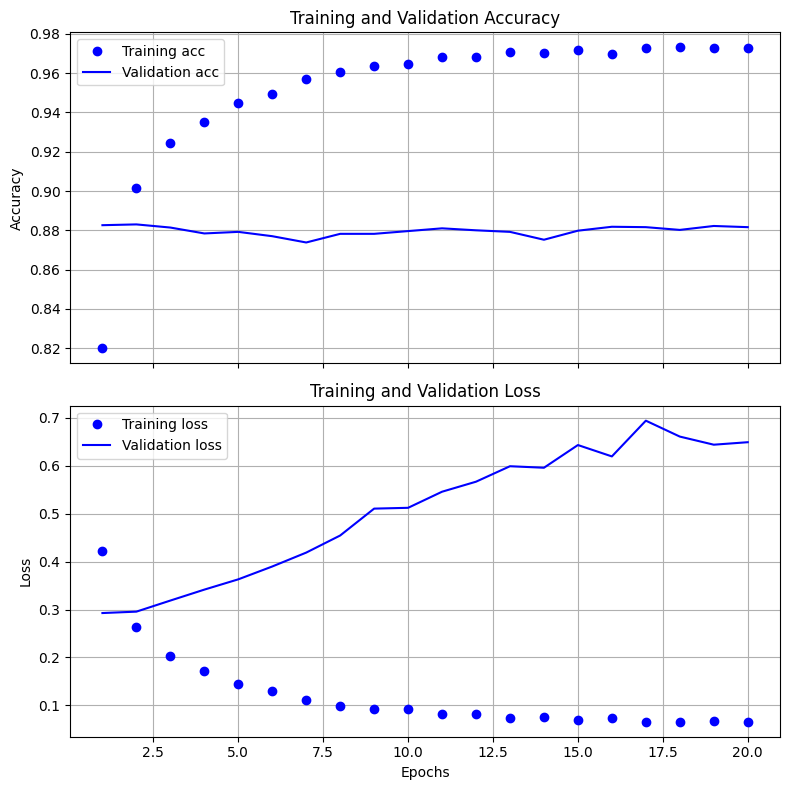

In [97]:
result_plot(history_tfidf)

In [98]:
y_pred_tfidf = model_tfidf.predict(test_text_tfidf)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [99]:
binary_predictions = (y_pred_tfidf >= 0.5).astype(int)
binary_predictions_tfidf = binary_predictions.flatten()
print(binary_predictions)

[[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]


In [100]:
accuracy_score(tst_labels, binary_predictions_tfidf)

0.85332

In [105]:
print(classification_report(tst_labels, binary_predictions_tfidf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86     12500
           1       0.88      0.82      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



___
$$****************************$$
___

## In our experiments, we observed significant differences in performance among the three text representation methods Count, Frequency, and TF-IDF. Frequency consistently outperformed the others, it's avoiding over fitting. These results highlight the importance of choosing an appropriate representation method, as it can greatly influence classification performance depending on the nature of the dataset. Also at another project can found another way is the best.

## Thanks